# Assignment No. 2

Name: yash vyas<br>
Roll No.: IT-2K24-97

## Question 5: Solving Linear Equations

### Method 5.1: Gauss Elimination Method

**Assumptions**

- A is a square matrix and b has matching size.
- A is non-singular.

**Algorithm (Gauss Elimination)**

1. Start
2. Read matrix A and vector b
3. Form augmented matrix [A|b]
4. For k = 0 to n - 1
5.    Choose pivot row and swap
6.    For i = k + 1 to n - 1
7.        Eliminate entries below pivot
8.    End For
9. End For
10. Back substitute to solve for x
11. Print solution x
12. Stop
13. End

In [7]:
def gauss_elimination(A, b):
    n = len(A)
    aug = [A[i][:] + [b[i]] for i in range(n)]
    steps = []

    for k in range(n):
        pivot = max(range(k, n), key=lambda i: abs(aug[i][k]))
        if abs(aug[pivot][k]) < 1e-12:
            raise ValueError("Matrix is singular or nearly singular.")
        aug[k], aug[pivot] = aug[pivot], aug[k]
        steps.append((f"Pivot k={k}", [row[:] for row in aug]))

        for i in range(k + 1, n):
            factor = aug[i][k] / aug[k][k]
            for j in range(k, n + 1):
                aug[i][j] -= factor * aug[k][j]
        steps.append((f"Eliminate k={k}", [row[:] for row in aug]))

    x = [0.0] * n
    for i in range(n - 1, -1, -1):
        s = sum(aug[i][j] * x[j] for j in range(i + 1, n))
        x[i] = (aug[i][n] - s) / aug[i][i]

    return x, steps


A = [[4.0, 1.0, 2.0], [3.0, 5.0, 1.0], [1.0, 1.0, 3.0]]
b = [4.0, 7.0, 3.0]
solution, steps = gauss_elimination(A, b)

for label, matrix in steps:
    print(label)
    for row in matrix:
        print(row)
    print()

print("Solution:", solution)

Pivot k=0
[4.0, 1.0, 2.0, 4.0]
[3.0, 5.0, 1.0, 7.0]
[1.0, 1.0, 3.0, 3.0]

Eliminate k=0
[4.0, 1.0, 2.0, 4.0]
[0.0, 4.25, -0.5, 4.0]
[0.0, 0.75, 2.5, 2.0]

Pivot k=1
[4.0, 1.0, 2.0, 4.0]
[0.0, 4.25, -0.5, 4.0]
[0.0, 0.75, 2.5, 2.0]

Eliminate k=1
[4.0, 1.0, 2.0, 4.0]
[0.0, 4.25, -0.5, 4.0]
[0.0, 0.0, 2.588235294117647, 1.2941176470588234]

Pivot k=2
[4.0, 1.0, 2.0, 4.0]
[0.0, 4.25, -0.5, 4.0]
[0.0, 0.0, 2.588235294117647, 1.2941176470588234]

Eliminate k=2
[4.0, 1.0, 2.0, 4.0]
[0.0, 4.25, -0.5, 4.0]
[0.0, 0.0, 2.588235294117647, 1.2941176470588234]

Solution: [0.5, 1.0, 0.4999999999999999]


Time Complexity: O(n^3)

Space Complexity: O(n^2)

### Method 5.2a: Jacobi Iteration Method

**Assumptions**

- A is square and diagonally dominant (or convergent).
- Initial guess x0 is given (or zero).
- Tolerance e > 0 and max iterations N are given.

**Algorithm (Jacobi Iteration)**

1. Start
2. Read A, b, x0, tolerance e, max iterations N
3. For i = 1 to N
4.    Compute new x using previous iteration values
5.    Compute error = max |x_new - x|
6.    If error <= e, print x and Stop
7.    Set x = x_new
8. End For
9. Print x as approximate solution
10. Stop
11. End

Solution: [1.0432848362598182, 2.269218329895499, -1.0817097237401818]
Iterations: 8


,iter,x,error
0,1,"[0.6, 2.272727272727273, -1.1]",2.272727
1,2,"[1.0472727272727274, 2.227272727272727, -0.992...",0.447273
2,3,"[1.0212727272727273, 2.277685950413223, -1.086...",0.094000
3,4,"[1.0451140495867768, 2.266776859504132, -1.076...",0.023841
4,5,"[1.0419748760330578, 2.2698752817430505, -1.08...",0.005859
5,6,"[1.0434565529676934, 2.2690572501878283, -1.08...",0.001482
6,7,"[1.043187214425244, 2.2692771914486713, -1.081...",0.000378
7,8,"[1.0432848362598182, 2.269218329895499, -1.081...",0.000098


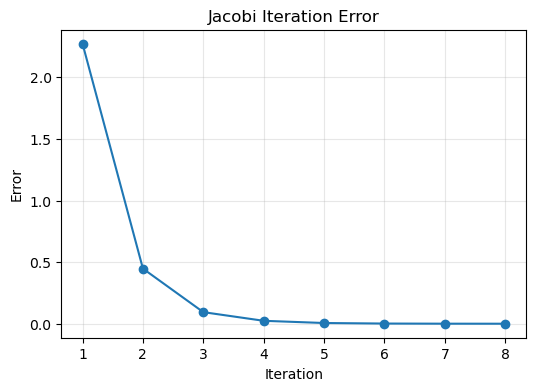

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

def jacobi_iteration(A, b, x0=None, tol=1e-10, max_iter=100):
    n = len(A)
    x = [0.0] * n if x0 is None else x0[:]
    rows = []

    for iteration in range(1, max_iter + 1):
        x_new = [0.0] * n
        for i in range(n):
            s = sum(A[i][j] * x[j] for j in range(n) if j != i)
            x_new[i] = (b[i] - s) / A[i][i]

        error = max(abs(x_new[i] - x[i]) for i in range(n))
        rows.append({"iter": iteration, "x": x_new[:], "error": error})
        x = x_new
        if error <= tol:
            return x, iteration, pd.DataFrame(rows)

    return x, max_iter, pd.DataFrame(rows)


A = [[10.0, -1.0, 2.0], [-1.0, 11.0, -1.0], [2.0, -1.0, 10.0]]
b = [6.0, 25.0, -11.0]
solution, iters, table = jacobi_iteration(A, b, tol=1e-4)
print("Solution:", solution)
print("Iterations:", iters)

display(table)

plt.figure(figsize=(6, 4))
plt.plot(table["iter"], table["error"], marker="o")
plt.title("Jacobi Iteration Error")
plt.xlabel("Iteration")
plt.ylabel("Error")
plt.grid(True, alpha=0.3)
plt.show()

Time Complexity: O(k * n^2)

Space Complexity: O(n)

### Method 5.2b: Gauss-Seidel Method

**Assumptions**

- A is square and diagonally dominant (or convergent).
- Initial guess x0 is given (or zero).
- Tolerance e > 0 and max iterations N are given.

**Algorithm (Gauss-Seidel Iteration)**

1. Start
2. Read A, b, x0, tolerance e, max iterations N
3. For i = 1 to N
4.    Update x in-place using latest values
5.    Compute error = max |x - x_old|
6.    If error <= e, print x and Stop
7. End For
8. Print x as approximate solution
9. Stop
10. End

Solution: [1.0432706647425722, 2.269230434262538, -1.0817310895222607]
Iterations: 5


,iter,x,error
0,1,"[0.6, 2.3272727272727276, -0.9872727272727273]",2.327273
1,2,"[1.0301818181818183, 2.276628099173554, -1.078...",0.430182
2,3,"[1.043337520661157, 2.2695421788129226, -1.081...",0.013156
3,4,"[1.0432968751314802, 2.2692348717164132, -1.08...",0.000307
4,5,"[1.0432706647425722, 2.269230434262538, -1.081...",0.000026


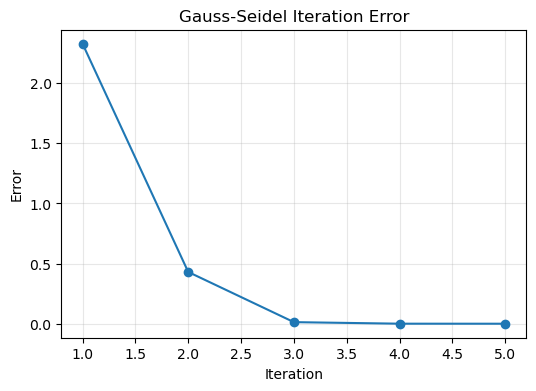

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

def gauss_seidel_iteration(A, b, x0=None, tol=1e-10, max_iter=100):
    n = len(A)
    x = [0.0] * n if x0 is None else x0[:]
    rows = []

    for iteration in range(1, max_iter + 1):
        x_old = x[:]
        for i in range(n):
            s1 = sum(A[i][j] * x[j] for j in range(i))
            s2 = sum(A[i][j] * x_old[j] for j in range(i + 1, n))
            x[i] = (b[i] - s1 - s2) / A[i][i]

        error = max(abs(x[i] - x_old[i]) for i in range(n))
        rows.append({"iter": iteration, "x": x[:], "error": error})
        if error <= tol:
            return x, iteration, pd.DataFrame(rows)

    return x, max_iter, pd.DataFrame(rows)


A = [[10.0, -1.0, 2.0], [-1.0, 11.0, -1.0], [2.0, -1.0, 10.0]]
b = [6.0, 25.0, -11.0]
solution, iters, table = gauss_seidel_iteration(A, b, tol=1e-4)
print("Solution:", solution)
print("Iterations:", iters)

display(table)

plt.figure(figsize=(6, 4))
plt.plot(table["iter"], table["error"], marker="o")
plt.title("Gauss-Seidel Iteration Error")
plt.xlabel("Iteration")
plt.ylabel("Error")
plt.grid(True, alpha=0.3)
plt.show()

Time Complexity: O(k * n^2)

Space Complexity: O(n)